In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file name from the dataset
file_path = "US_Accidents_March23.csv"

# Load dataset into Pandas DataFrame
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sobhanmoosavi/us-accidents",
    file_path,
)

/tmp/ipython-input-2724125543.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'us-accidents' dataset.


In [3]:
import pandas as pd
data_dict = pd.read_csv("/content/drive/MyDrive/Machine Learning Practical Project/us_accidents_data_dictionary.csv")

data_dict=data_dict[data_dict['Relevance to Severity'] != 'Low']

In [4]:
required_cols = list(data_dict['Feature Name'])
print(len(required_cols))

26


In [5]:
data = df[required_cols]
data.head()

data.shape
# 7728394, 26

data.columns
# (['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'Description',
#        'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
#        'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
#        'Precipitation(in)', 'Weather_Condition', 'Crossing', 'Give_Way',
#        'Junction', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
#        'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
#        'Astronomical_Twilight'],
#       dtype='object'

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'Description',
       'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Crossing', 'Give_Way',
       'Junction', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

**EDA**

Data Information

In [6]:
data.dtypes

,0
Severity,int64
Start_Time,object
End_Time,object
Distance(mi),float64
Description,object
Weather_Timestamp,object
Temperature(F),float64
Wind_Chill(F),float64
Humidity(%),float64
Pressure(in),float64


In [7]:
numeric_cols = data.select_dtypes(include='number').columns
categorical_cols = data.select_dtypes(include='object').columns
bool_cols = data.select_dtypes(include='bool').columns

Heatmap

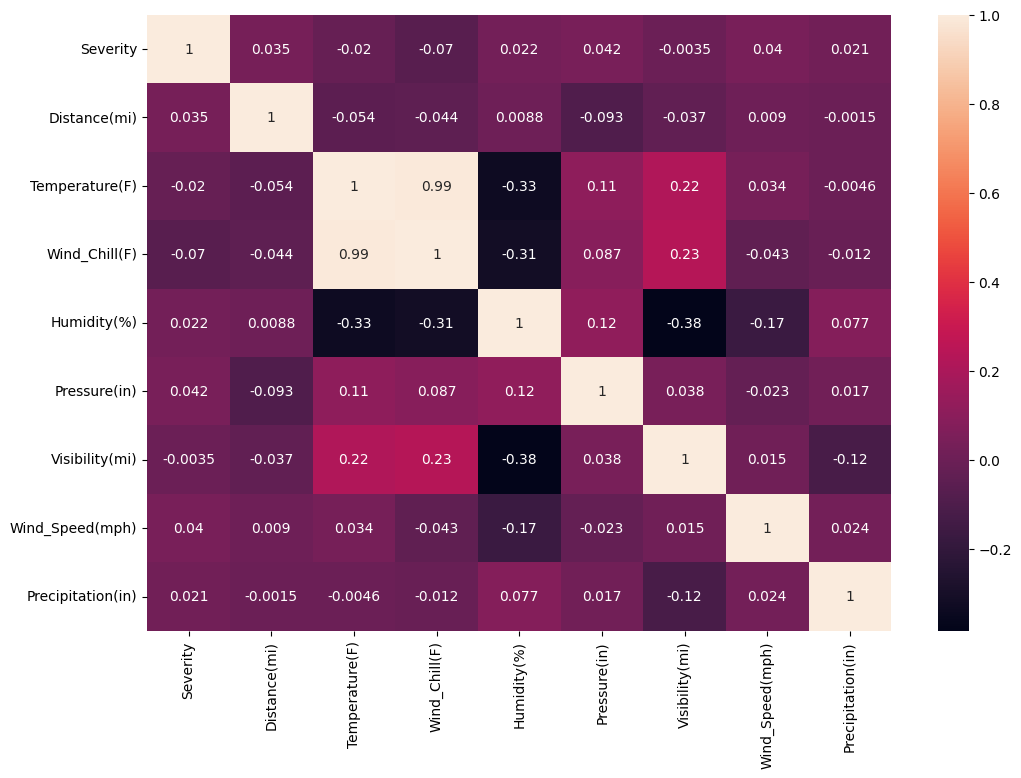

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(data[numeric_cols].corr(), annot=True)
plt.show()

It shows that the Wind Feature is highly correlated with the Tempreture Feature, so by thumb rule of feature that their should not any feature correlated with each other we have to eliminated of them which comtribute low to predict target

**Categorical Columns**

['Start_Time', 'End_Time', 'Description', 'Weather_Timestamp',
       'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

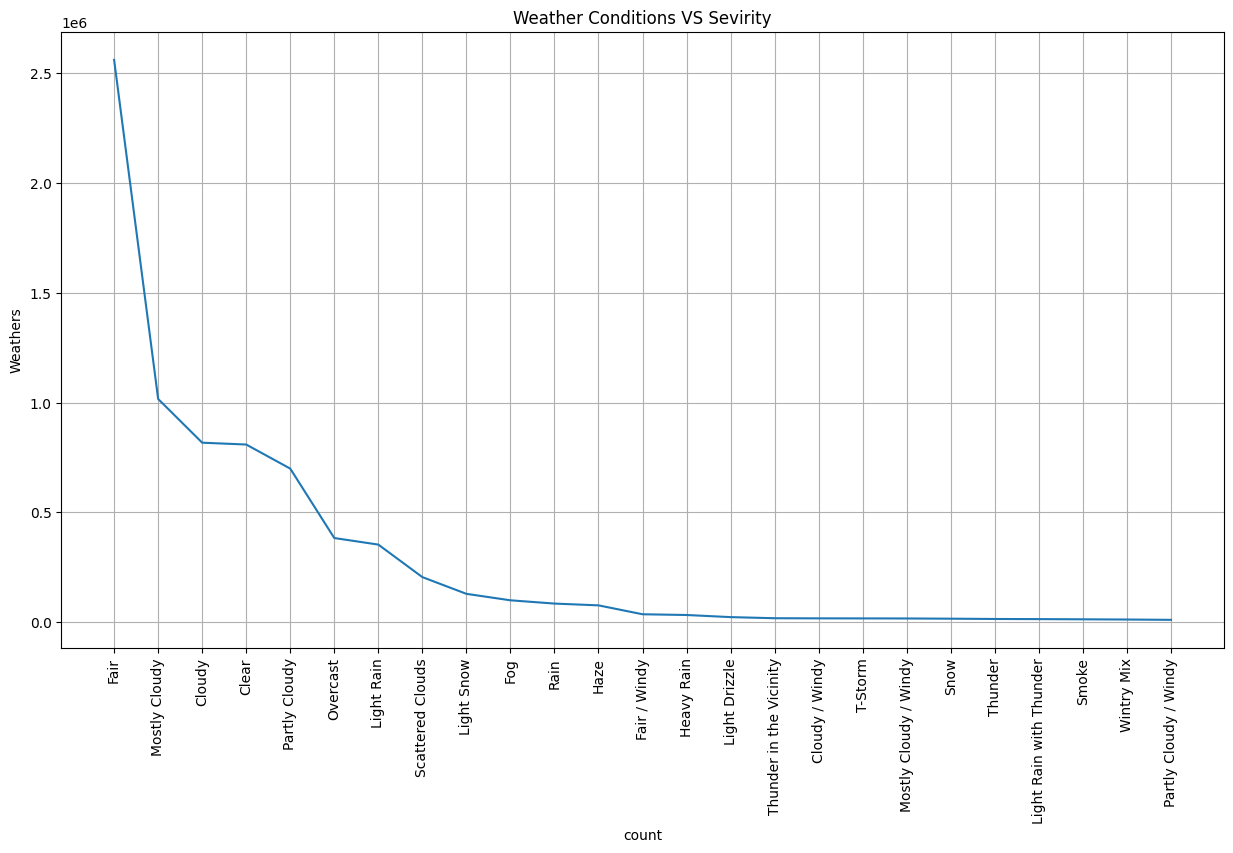

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

a = data.Weather_Condition.value_counts()
a = a.sort_values(ascending=False)
# print(a.iloc[:25])
# sns.barplot(x=a.iloc[:5], hue=data.Severity)
plt.figure(figsize=(15,8))
plt.plot(a.iloc[:25])
plt.title("Weather Conditions VS Sevirity")
plt.xlabel("count")
plt.ylabel("Weathers")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Severity with respect to the Weather conditions

In [105]:
from itertools import combinations
weather = data.Weather_Condition.unique()
# print(weather)
weathers = data.Weather_Condition.value_counts().sort_values(ascending=False).reset_index()
weathers.columns = ['Weather_Condition', 'Count']

frequent_weather_list = list(weathers.head(25).Weather_Condition)

from itertools import combinations
frequent_weather_list = list(combinations(frequent_weather_list, 2))

# print(frequent_weather_list)
# print(frequent_weather_list[0][0])

fig, axs = plt.subplots(len(frequent_weather_list), 2, figsize=(12,6*len(frequent_weather_list)))

for i in range(0, len(frequent_weather_list)):
  axs[i, 0].hist(data[data.Weather_Condition == frequent_weather_list[i][0]].Severity)
  # axs[i, 0].set_title(f"{frequent_weather_list[i]} vs Severity")
  # axs[i, 0].set_xlabel("Severity")
  # axs[i, 0].set_ylabel("Count")
  # axs[i, 0].grid(True)

  axs[i, 1].hist(data[data.Weather_Condition == frequent_weather_list[i][1]].Severity)
  # axs[i, 1].set_title(f"{frequent_weather_list[i]} vs Severity")
  # axs[i, 1].set_xlabel("Severity")
  # axs[i, 1].set_ylabel("Count")
  # axs[i, 1].grid(True)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7a466f613ce0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7a466f611260> (for post_execute):


KeyboardInterrupt: 